In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn 
from sklearn import mixture
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

In [2]:
x = np.load("formationchannels.npy")

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]]


<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_17988\390819152.py:3: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Black hole mass $[M_\odot]$")


Text(0.5, 0, 'Black hole mass $[M_\\odot]$')

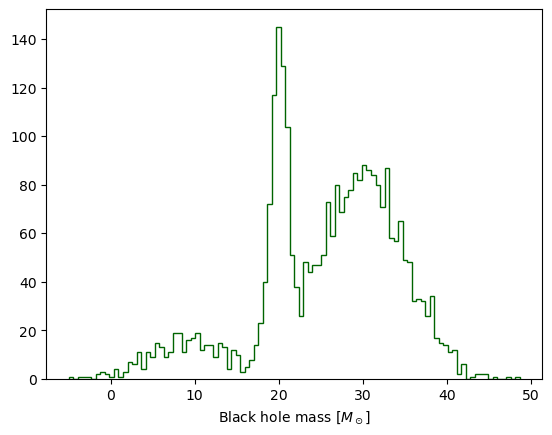

In [3]:
print(x)
plt.hist(x, bins=100, histtype="step", color="darkgreen") #dai dati vedi la comparsa di tre picchi gaussiani
plt.xlabel("Black hole mass $[M_\odot]$")

In [6]:
#x=np.linspace(0, 5, 6) #per far venire esempio più semplice
print(x, x.shape) #dati come riga
print(x[np.newaxis,:], x[np.newaxis,:].shape) #dati come colonna
print(x[:,np.newaxis], x[:,np.newaxis].shape) 

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]] (2950, 1)
[[[17.12172682]
  [ 5.94121793]
  [ 6.35914124]
  ...
  [34.34170191]
  [30.27018478]
  [25.93264098]]] (1, 2950, 1)
[[[17.12172682]]

 [[ 5.94121793]]

 [[ 6.35914124]]

 ...

 [[34.34170191]]

 [[30.27018478]]

 [[25.93264098]]] (2950, 1, 1)


In [8]:
print(x.shape[0])

2950


In [11]:
#mi serve per generare un modello come mixture di gaussiane 
sklearn.mixture.GaussianMixture(n_components=x.shape[0])
gm = GaussianMixture(n_components= 1).fit(x)

C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(ex

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows

[20945.9726085902, 20753.327537970617, 20083.07894669639, 20103.501899709256, 20112.982763942866, 20122.48770491688, 20128.93866083984, 20132.41126582442, 20133.381790585274, 20136.81842116312]
10


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


Text(0, 0.5, 'information criterion')

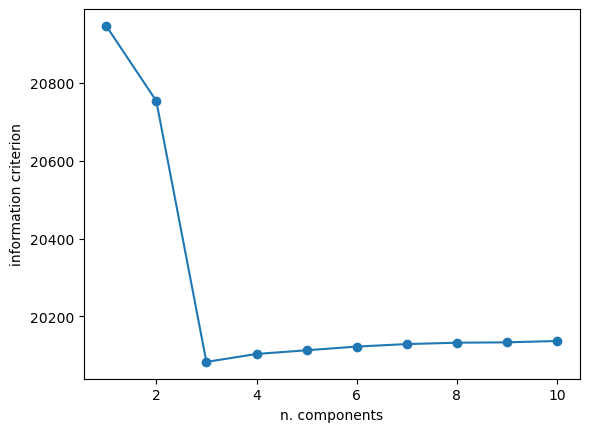

In [13]:
total_aic = []
for i in range(1,10+1): #espremo non compreso
    gm = GaussianMixture(i).fit(x)
    aic = gm.aic(x) #mi serve per trovare con quante gaussiane è meglio lavorare
    total_aic.append(aic)
    #print(aic)

print(total_aic)
print(len(total_aic))
plt.plot(np.arange(1,11), total_aic, marker="o") #attenzione devo contare uno step in più per come funziona arange
plt.xlabel('n. components')
plt.ylabel('information criterion')

<>:16: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_17988\990858565.py:16: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Black hole mass $[M_\odot]$")
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


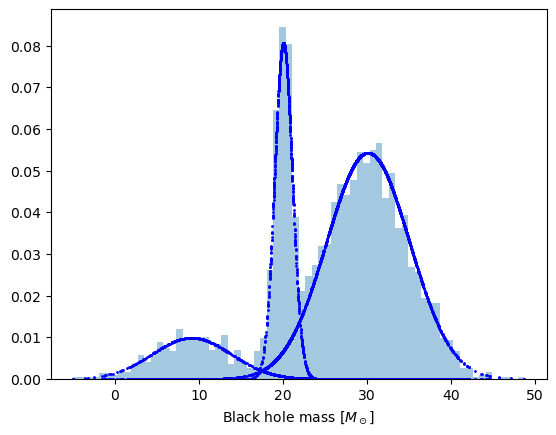

In [15]:
#best model with 3 gaussian 
N = 3

gm = GaussianMixture(n_components= N).fit(x) #entrata zero, due dimensioni
#CREAZIONE DEI PARAMETRI PER LE GAUSSIANE
gm_mean = gm.means_
gm_cov = gm.covariances_ 
gm_weight = gm.weights_
gm_sigma = np.sqrt(gm_cov)

plt.hist(x,bins=70, density=True, alpha=0.4)
pdf_total = np.zeros_like(x) #array pieno di zeri ma come
for i in range(N): 
    pdf_gauss = norm.pdf(x, loc=gm_mean[i], scale=gm_sigma[i])
    plt.scatter(x, gm_weight[i]*pdf_gauss, s=1, color="blue")
    plt.xlabel("Black hole mass $[M_\odot]$")
    pdf_total += gm_weight[i] * pdf_gauss #sommo il contributo da tutte e tre le gaussiane pesando su tutta la griglia

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_17988\3960798398.py:3: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Black hole mass $[M_\odot]$")


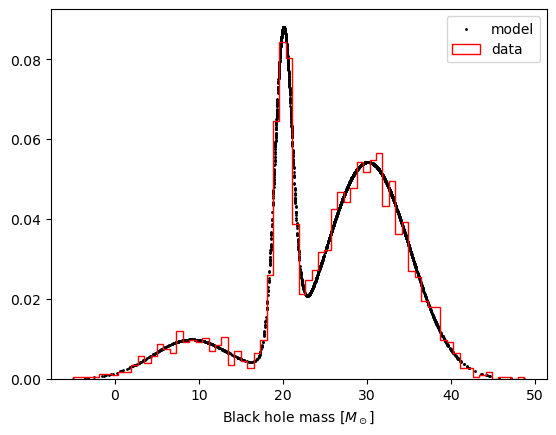

In [17]:
plt.scatter(x,pdf_total, s=1, color="black", label="model")
plt.hist(x,bins=70, density=True, histtype='step', color="red", label="data")
plt.xlabel("Black hole mass $[M_\odot]$")
plt.legend()

In [20]:
log_prob = gm.score_samples(x.reshape(-1,1))
PDF_tot_plot = np.exp(log_prob)
responsibilities = gm.predict_proba(x.reshape(-1,1))

In [24]:
print(responsibilities)
print(len(responsibilities))
print(len(PDF_tot_plot))

[[3.00670358e-01 2.95483871e-01 4.03845771e-01]
 [4.24744223e-05 7.31523686e-39 9.99957526e-01]
 [6.05837029e-05 1.33407517e-36 9.99939416e-01]
 ...
 [9.99999870e-01 1.30485324e-40 1.30136166e-07]
 [9.99993316e-01 3.98424540e-21 6.68366512e-06]
 [9.99590789e-01 3.20926134e-07 4.08889749e-04]]
2950
2950


Text(0.5, 0, 'responsability')

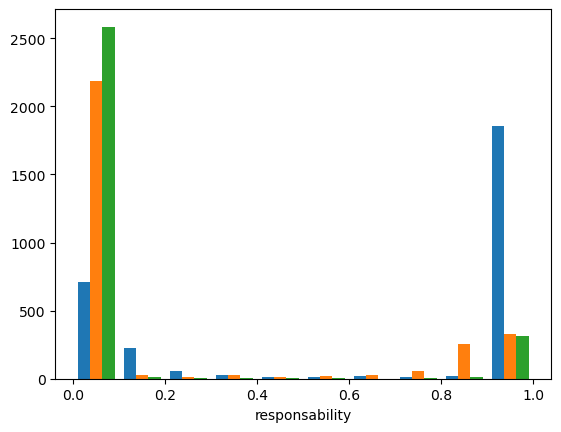

In [26]:
plt.hist(responsibilities, bins=10)
plt.xlabel("responsability")

Text(0, 0.5, 'total PDF')

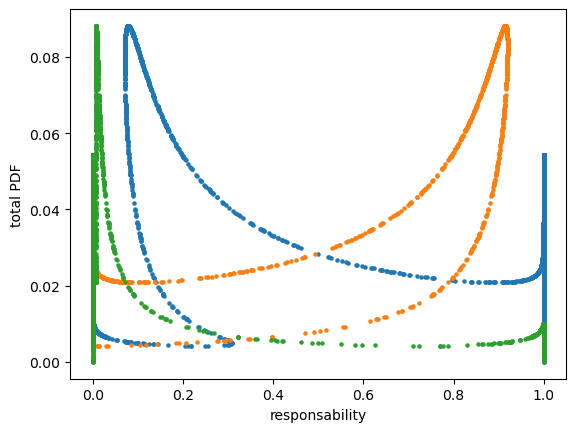

In [28]:
plt.scatter(responsibilities[:,0], PDF_tot_plot, s=5)
plt.scatter(responsibilities[:,1], PDF_tot_plot, s=5)
plt.scatter(responsibilities[:,2], PDF_tot_plot, s=5)
plt.xlabel("responsability")
plt.ylabel("total PDF")

In [32]:
PDF_tot_plot_cluster = responsibilities * PDF_tot_plot[:, np.newaxis]

<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_17988\49484956.py:5: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Black hole mass $[M_\odot]$")


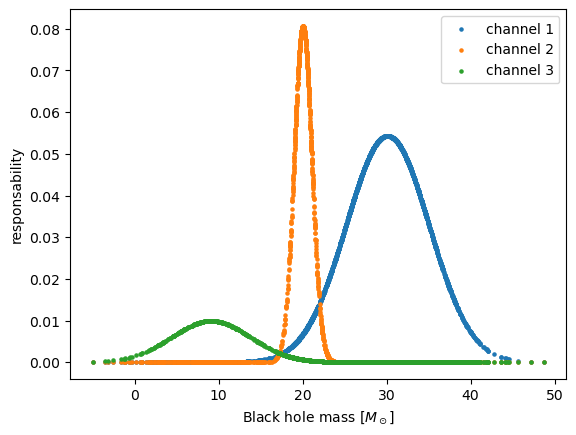

In [34]:
plt.scatter(x, PDF_tot_plot_cluster[:,0], s=5, label="channel 1")
plt.scatter(x,PDF_tot_plot_cluster[:,1], s=5, label="channel 2")
plt.scatter(x, PDF_tot_plot_cluster[:,2], s=5, label ="channel 3")
plt.ylabel("responsability")
plt.xlabel("Black hole mass $[M_\odot]$")
plt.legend()